# Machine learning model to financial predictions

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

In [3]:
notebook_dir = Path().resolve()

# Data folder
data_folder = notebook_dir.parent / "Data"
data_folder.mkdir(exist_ok=True)  # ensures folder exists

In [4]:
quarterly_data_path = data_folder / "quarterly_data.csv"
df = pd.read_csv(quarterly_data_path)

df.shape

(5078, 110)

In [5]:
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

In [6]:
# tickers, min-max date, count of daily observations
df.groupby(['ticker'])['date'].agg(['min','max','count'])

,min,max,count
ticker,,,
6501.T,2001-12-31,2025-09-30,96
6758.T,2001-12-31,2025-09-30,96
6861.T,2002-12-31,2025-09-30,92
7203.T,2001-12-31,2025-09-30,96
7267.T,2001-12-31,2025-09-30,96
9432.T,2001-12-31,2025-09-30,96
9984.T,2001-12-31,2025-09-30,96
AAPL,2001-12-31,2025-09-30,96
ABBV,2014-12-31,2025-09-30,44


# 1. Feature engineering

In [7]:
for i, col in enumerate(df.columns, start=1):
    print(i, col)


1 ticker
2 date
3 year
4 quarter
5 close
6 ln_volume
7 daily_growth
8 weekly_growth
9 biweekly_growth
10 monthly_growth
11 spread_open_close
12 spread_high_low
13 rel_spread_oc
14 rel_spread_hl
15 vol_10d
16 return_1q
17 return_2q
18 return_3q
19 vol_3q
20 momentum_3q
21 qma_2
22 qma_4
23 qma_8
24 marketCap
25 beta
26 trailingPE
27 forwardPE
28 trailing_PEG
29 priceToBook
30 dividendYield
31 debt_to_equity
32 current_ratio
33 cash_ratio
34 working_capital
35 working_capital_ratio
36 retained_earnings_to_assets
37 long_term_debt_to_equity
38 operating_cf_margin
39 free_cf_margin
40 pct_held_by_inst
41 institutional_holders_count
42 esg_env
43 esg_soc
44 esg_gov
45 recent_rating_changes
46 strong_to_total_reco_ratio
47 days_to_next_earnings
48 dividend_stability
49 companyName
50 sector
51 fullTimeEmployees
52 region
53 gdp_us
54 gdp_us_yoy
55 gdp_us_qoq
56 cpi_us
57 cpi_us_yoy
58 cpi_us_qoq
59 unemployment_us
60 unemployment_us_yoy
61 unemployment_us_qoq
62 interest_us
63 interest_us_yo

In [8]:
df['buy_signal'].value_counts()

buy_signal
True     3022
False    2056
Name: count, dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078 entries, 0 to 5077
Columns: 110 entries, ticker to buy_signal
dtypes: bool(1), datetime64[ns](1), float64(97), int64(7), object(4)
memory usage: 4.2+ MB


In [10]:
df.select_dtypes(include='int64').columns

Index(['year', 'quarter', 'marketCap', 'institutional_holders_count',
       'recent_rating_changes', 'days_to_next_earnings', 'fullTimeEmployees'],
      dtype='object')

In [11]:
CATEGORICAL = ['ticker', 'sector', 'region']

TO_PREDICT = ['buy_signal']

USED_BUY_SIGNAL_LABEL = ['qma_2', 'qma_4', 'return_2q', 'sp500_qoq','momentum_3q', 'trailingPE', 'interest_us_qoq']

TO_DROP = ['companyName', 'date', 'year', 'quarter', 'close'] + USED_BUY_SIGNAL_LABEL + CATEGORICAL

In [12]:
for cat in CATEGORICAL:
    print(df[cat].value_counts())
    print('\n')

ticker
AAPL       96
CVX        96
GE         96
MMM        96
SAP.DE     96
IFX.DE     96
FME.DE     96
BAS.DE     96
BAYN.DE    96
SIE.DE     96
ALV.DE     96
DBK.DE     96
HSBA.L     96
BP.L       96
ULVR.L     96
OR.PA      96
ASML.AS    96
NOVN.SW    96
ROG.SW     96
UBSG.SW    96
7203.T     96
6758.T     96
9432.T     96
9984.T     96
7267.T     96
MSFT       96
CAT        96
XOM        96
UNH        96
NVDA       96
ORCL       96
IBM        96
AMZN       96
CSCO       96
INTU       96
JNJ        96
PFE        96
MS         96
MRK        96
LLY        96
AMGN       96
BMY        96
KO         96
PG         96
PEP        96
JPM        96
BAC        96
GS         96
6501.T     96
6861.T     92
AIR.PA     90
GOOGL      78
META       47
ABBV       44
SHL.DE     23
Name: count, dtype: int64


sector
Technology                1148
Healthcare                1123
Financial Services         768
Industrials                570
Consumer Defensive         480
Communication Services     317
Co

### 1.1 Generate dummy variables for categorical features

In [13]:
dummy_variables = pd.get_dummies(df[CATEGORICAL], dtype='int32')

In [14]:
dummy_variables.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078 entries, 0 to 5077
Data columns (total 67 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   ticker_6501.T                  5078 non-null   int32
 1   ticker_6758.T                  5078 non-null   int32
 2   ticker_6861.T                  5078 non-null   int32
 3   ticker_7203.T                  5078 non-null   int32
 4   ticker_7267.T                  5078 non-null   int32
 5   ticker_9432.T                  5078 non-null   int32
 6   ticker_9984.T                  5078 non-null   int32
 7   ticker_AAPL                    5078 non-null   int32
 8   ticker_ABBV                    5078 non-null   int32
 9   ticker_AIR.PA                  5078 non-null   int32
 10  ticker_ALV.DE                  5078 non-null   int32
 11  ticker_AMGN                    5078 non-null   int32
 12  ticker_AMZN                    5078 non-null   int32
 13  ticker_ASML.AS    

In [15]:
# Concatenate the dummy variables with the original DataFrame
df_with_dummies = pd.concat([df, dummy_variables], axis=1)

### 1.2 Correlation analysis

In [16]:
df_with_dummies.drop(columns = TO_DROP).corr()[TO_PREDICT].sort_values(by=TO_PREDICT, ascending=False)

,buy_signal
buy_signal,1.000000
return_3q,0.602103
spy_yoy,0.325405
efa_yoy,0.325219
sp500_yoy,0.324153
...,...
vix_yoy,-0.216892
rel_spread_oc,-0.237795
rel_spread_hl,-0.252313
vol_10d,-0.266358


## 2. Random Forest Model

In [17]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [18]:
df_model = df_with_dummies.copy()

In [19]:
# 1. Sort chronologically
df_model = df_model.sort_values(['date', 'ticker']).reset_index(drop=True)

# 2. Automatic 80/20 date cutoff

start_date = df_model['date'].min()
end_date = df_model['date'].max()
cutoff_date = start_date + (end_date - start_date) * 0.8

print(f"Train: {start_date.date()} → {cutoff_date.date()}")
print(f"Test:  {cutoff_date.date()} → {end_date.date()}")



Train: 2001-12-31 → 2020-12-30
Test:  2020-12-30 → 2025-09-30


In [20]:
train_df = df_model[df_model['date'] < cutoff_date]
test_df  = df_model[df_model['date'] >= cutoff_date]

In [21]:
# 3. Features and target
X_train = train_df.drop(CATEGORICAL+TO_PREDICT+TO_DROP, axis=1)
y_train = train_df['buy_signal']

X_test  = test_df.drop(CATEGORICAL+TO_PREDICT+TO_DROP, axis=1)
y_test  = test_df['buy_signal']

In [22]:
# 4. Define model and param grid
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}


In [23]:
# 5. TimeSeriesSplit for CV
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='accuracy',
    cv=tscv,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Fitting 5 folds for each of 96 candidates, totalling 480 fits

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Score: 0.857918552036199


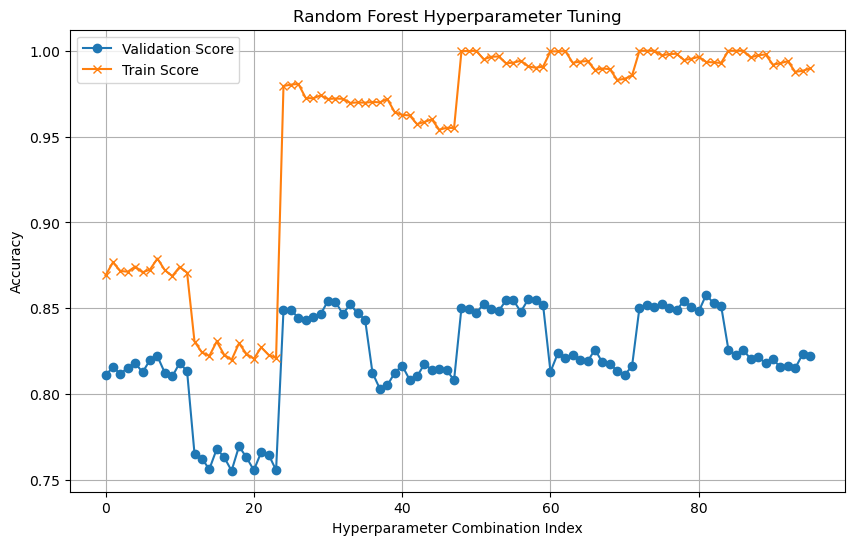

In [24]:
# 6. Visualize hyperparameter tuning results

results = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(10, 6))
plt.plot(results['mean_test_score'], label='Validation Score', marker='o')
plt.plot(results['mean_train_score'], label='Train Score', marker='x')
plt.xlabel('Hyperparameter Combination Index')
plt.ylabel('Accuracy')
plt.title('Random Forest Hyperparameter Tuning')
plt.legend()
plt.grid(True)
plt.show()



In [25]:
# 7. Train best model and evaluate
# =============================
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)

y_pred = best_rf.predict(X_test)

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Test Accuracy: 0.8854545454545455

Classification Report:
               precision    recall  f1-score   support

       False       0.89      0.79      0.84       411
        True       0.88      0.94      0.91       689

    accuracy                           0.89      1100
   macro avg       0.89      0.87      0.87      1100
weighted avg       0.89      0.89      0.88      1100



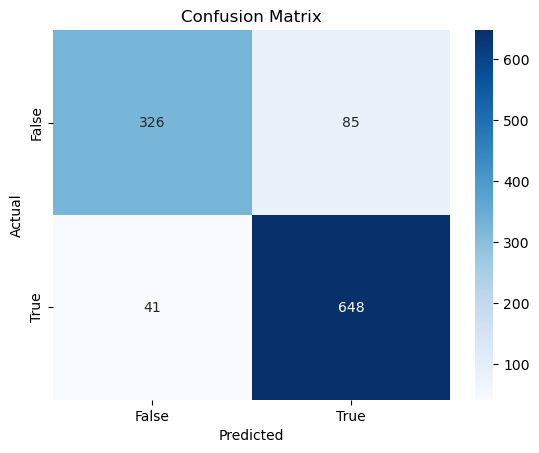

In [26]:
cm = confusion_matrix(y_test, y_pred)

labels = sorted(df['buy_signal'].unique())
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


## Model Visuals

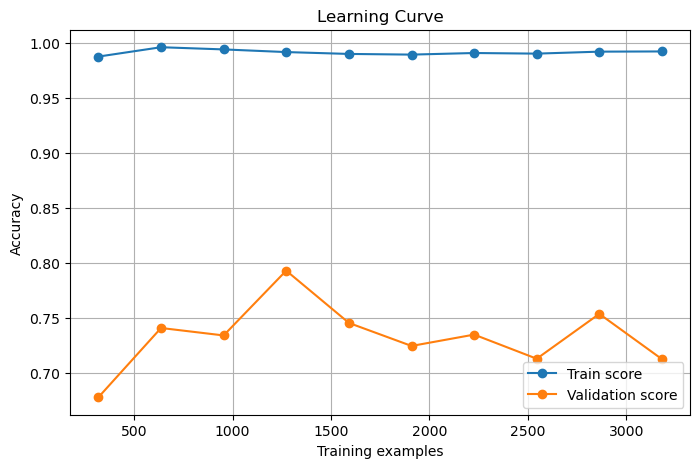

In [27]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    grid_search.best_estimator_,
    X_train, y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train score')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation score')
plt.xlabel('Training examples')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.grid(True)
plt.show()


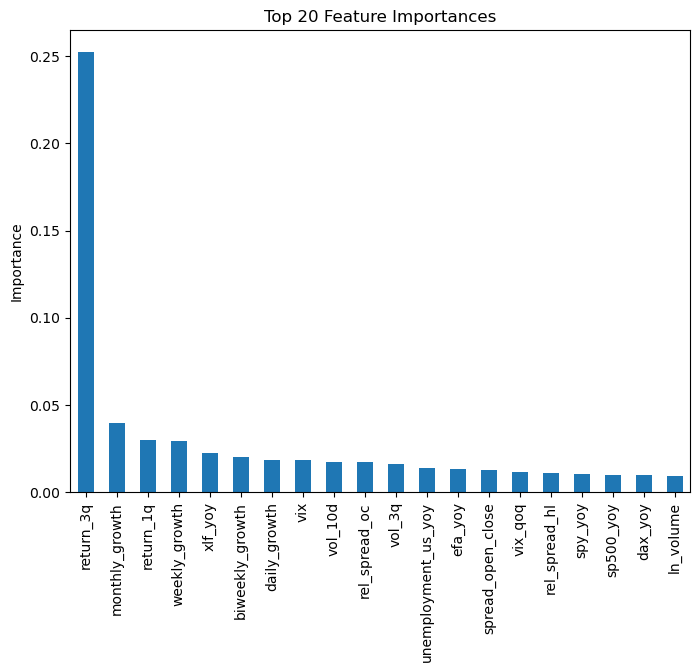

In [28]:
importances = grid_search.best_estimator_.feature_importances_
features = X_train.columns
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False).head(20)

plt.figure(figsize=(8,6))
feat_imp.plot(kind='bar')
plt.title('Top 20 Feature Importances')
plt.ylabel('Importance')
plt.show()

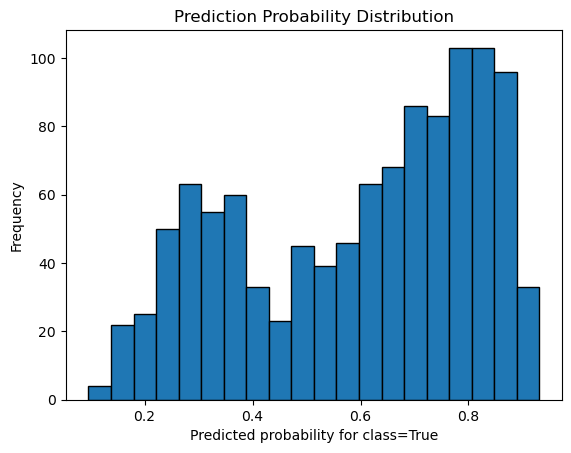

In [29]:
probs = grid_search.best_estimator_.predict_proba(X_test)[:, 1]
plt.hist(probs, bins=20, edgecolor='k')
plt.xlabel('Predicted probability for class=True')
plt.ylabel('Frequency')
plt.title('Prediction Probability Distribution')
plt.show()

# Data set for a simulation of trading strategy


In [37]:
# predict on a full dataset
y_pred_all = best_rf.predict(df_model.drop(CATEGORICAL+TO_PREDICT+TO_DROP, axis=1))
y_pred_all.shape

(5078,)

In [38]:
df_model['pred_rf'] = y_pred_all

In [39]:
df_model[['buy_signal', 'pred_rf']].sample(10)

,buy_signal,pred_rf
4857,True,True
3344,True,True
2757,False,False
4798,True,True
3769,True,True
2716,True,True
2817,True,True
4057,True,True
4742,True,True
1327,False,False


In [43]:
rf_model_pred = df_model[['date', 'ticker', 'close','buy_signal', 'pred_rf']].copy()
rf_model_pred.shape

(5078, 5)

In [44]:
# Save data for simulation
rf_model_pred.to_csv(data_folder / "rf_model_pred.csv", index=False)